In [1]:
import pandas  as pd

In [2]:
teams = pd.read_csv(r"C:\Users\JOHNFRANK TOBECHUKWU\Desktop\teams.csv")

In [3]:
teams

,team,year,athletes,events,age,height,weight,prev_medals,medals
0,AFG,1964,8,8,22.0,161.0,64.2,0.0,0
1,AFG,1968,5,5,23.2,170.2,70.0,0.0,0
2,AFG,1972,8,8,29.0,168.3,63.8,0.0,0
3,AFG,1980,11,11,23.6,168.4,63.2,0.0,0
4,AFG,2004,5,5,18.6,170.8,64.8,0.0,0
...,...,...,...,...,...,...,...,...,...
2009,ZIM,2000,26,19,25.0,179.0,71.1,0.0,0
2010,ZIM,2004,14,11,25.1,177.8,70.5,0.0,3
2011,ZIM,2008,16,15,26.1,171.9,63.7,3.0,4
2012,ZIM,2012,9,8,27.3,174.4,65.2,4.0,0


In [ ]:
LETS REMOVE THE SUBSETS OF THE COLUMNS FOR PREDICTION 

In [61]:
teams

,year,athletes,age,prev_medals,medals
0,1964,8,22.0,0.0,0
1,1968,5,23.2,0.0,0
2,1972,8,29.0,0.0,0
3,1980,11,23.6,0.0,0
4,2004,5,18.6,0.0,0
...,...,...,...,...,...
2009,2000,26,25.0,0.0,0
2010,2004,14,25.1,0.0,3
2011,2008,16,26.1,3.0,4
2012,2012,9,27.3,4.0,0


In [62]:
teams = teams[["year","athletes","age", "prev_medals","medals"]]
teams

,year,athletes,age,prev_medals,medals
0,1964,8,22.0,0.0,0
1,1968,5,23.2,0.0,0
2,1972,8,29.0,0.0,0
3,1980,11,23.6,0.0,0
4,2004,5,18.6,0.0,0
...,...,...,...,...,...
2009,2000,26,25.0,0.0,0
2010,2004,14,25.1,0.0,3
2011,2008,16,26.1,3.0,4
2012,2012,9,27.3,4.0,0


In [15]:
teams

,year,athletes,age,prev_medals,medals
0,1964,8,22.0,0.0,0
1,1968,5,23.2,0.0,0
2,1972,8,29.0,0.0,0
3,1980,11,23.6,0.0,0
4,2004,5,18.6,0.0,0
...,...,...,...,...,...
2009,2000,26,25.0,0.0,0
2010,2004,14,25.1,0.0,3
2011,2008,16,26.1,3.0,4
2012,2012,9,27.3,4.0,0


In [12]:
teams.isnull().sum()

team           0
year           0
athletes       0
age            0
prev_medals    0
medals         0
dtype: int64

In [ ]:
TO MAKE GOOD PREDICTION , YOU MUST GET YOUUR CORRELATION . ATHL VS PREV_MODELS 
HAVE HIGH CORRELATION WHILE, AGE  HAS LOW  CORRELATION 

In [16]:
teams.corr() ["medals"]

year          -0.034870
athletes       0.839909
age            0.023231
prev_medals    0.920048
medals         1.000000
Name: medals, dtype: float64

In [ ]:
LETS LOOK AT HOW THE CORRELATION IS IN THE GRAPH

In [19]:
import seaborn as sns

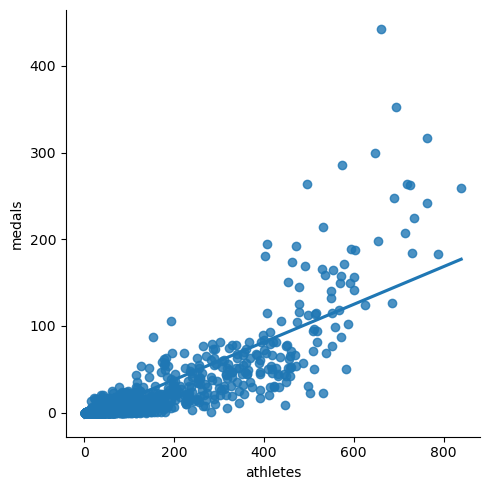

In [20]:
sns.lmplot( x ="athletes", y="medals", data = teams , fit_reg = True,ci = None)

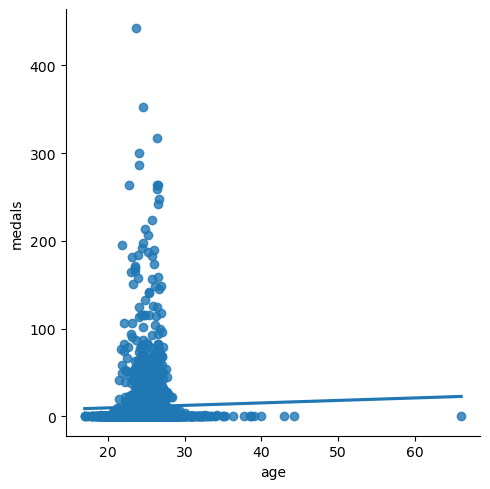

In [21]:
sns.lmplot( x ="age", y="medals", data = teams , fit_reg = True,ci = None)

<Axes: ylabel='Frequency'>

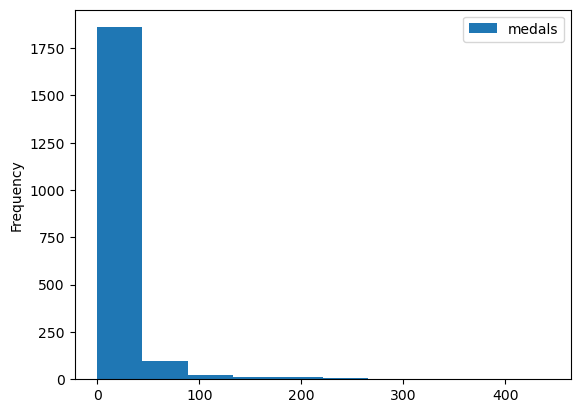

In [22]:
teams.plot.hist(y="medals")

In [25]:
teams[teams.isnull().any(axis=1)]
teams

,year,athletes,age,prev_medals,medals
0,1964,8,22.0,0.0,0
1,1968,5,23.2,0.0,0
2,1972,8,29.0,0.0,0
3,1980,11,23.6,0.0,0
4,2004,5,18.6,0.0,0
...,...,...,...,...,...
2009,2000,26,25.0,0.0,0
2010,2004,14,25.1,0.0,3
2011,2008,16,26.1,3.0,4
2012,2012,9,27.3,4.0,0


In [27]:
teams.isnull().sum()

year           0
athletes       0
age            0
prev_medals    0
medals         0
dtype: int64

In [ ]:
SPLIT OUR DATA BASED ON TIME 
TRAIN THE LAST 2 YEARS AND TEST THE PREVIOUS YEARS 

In [29]:
train =teams[teams["year"]< 2012].copy()
test = teams[teams["year"]>= 2012].copy()

In [30]:
train.shape

(1609, 5)

In [31]:
test.shape

(405, 5)

In [43]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [44]:
predictors =["athletes","prev_medals"]
target = "medals"

In [45]:
reg.fit(train[predictors],train["medals"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
predictions = reg.predict(test[predictors])

In [48]:
test["predictions"]= predictions

In [49]:
test

,year,athletes,age,prev_medals,medals,predictions
6,2012,6,24.8,1.0,1,-0.961221
7,2016,3,24.7,1.0,0,-1.176333
23,2012,10,25.7,0.0,0,-1.425032
24,2016,6,23.7,0.0,0,-1.711847
35,2012,39,24.8,2.0,1,2.155629
...,...,...,...,...,...,...
1983,2016,3,19.3,0.0,0,-1.926958
2001,2012,7,22.6,0.0,0,-1.640143
2002,2016,7,24.1,0.0,0,-1.640143
2012,2012,9,27.3,4.0,0,1.505767


In [50]:
test.loc[test["predictions"]<0,"predictions"] = 0

In [51]:
test["predictions"] = test["predictions"].round()

In [52]:
test

,year,athletes,age,prev_medals,medals,predictions
6,2012,6,24.8,1.0,1,0.0
7,2016,3,24.7,1.0,0,0.0
23,2012,10,25.7,0.0,0,0.0
24,2016,6,23.7,0.0,0,0.0
35,2012,39,24.8,2.0,1,2.0
...,...,...,...,...,...,...
1983,2016,3,19.3,0.0,0,0.0
2001,2012,7,22.6,0.0,0,0.0
2002,2016,7,24.1,0.0,0,0.0
2012,2012,9,27.3,4.0,0,2.0


In [54]:
from sklearn.metrics import mean_absolute_error


In [55]:
error = mean_absolute_error(test["medals"], test["predictions"])

In [56]:
error

3.2987654320987656

In [57]:
teams.describe()["medals"]

count    2014.000000
mean       10.990070
std        33.627528
min         0.000000
25%         0.000000
50%         0.000000
75%         5.000000
max       442.000000
Name: medals, dtype: float64

In [60]:
teams

,year,athletes,age,prev_medals,medals
0,1964,8,22.0,0.0,0
1,1968,5,23.2,0.0,0
2,1972,8,29.0,0.0,0
3,1980,11,23.6,0.0,0
4,2004,5,18.6,0.0,0
...,...,...,...,...,...
2009,2000,26,25.0,0.0,0
2010,2004,14,25.1,0.0,3
2011,2008,16,26.1,3.0,4
2012,2012,9,27.3,4.0,0
